# 04 · Compute engines: numpy vs numba vs torch

The same model can score and accumulate through different compute engines. The numpy/vectorized path is the default; the numba fused-mixture kernel and the torch engine swap only the score/accumulate kernels (the distribution math and the M-step are unchanged), so results match. Below we find where each wins and quantify a built-in EM overhead.


In [1]:

import time, io, numpy as np
import matplotlib.pyplot as plt
from mixle.stats import *
from mixle.inference.estimation import optimize
from mixle.stats.compute.sequence import seq_estimate

def bench(fn, repeat=3):
    """Best-of-`repeat` wall-clock seconds for calling fn()."""
    best = float('inf')
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

def em_step_time(enc, est, model, iters=10):
    """Mean seconds per EM iteration (E+M step, excludes the convergence LL pass)."""
    from mixle.stats.compute.sequence import seq_estimate
    t0 = time.perf_counter()
    m = model
    for _ in range(iters):
        m = seq_estimate(enc, est, prev_estimate=m)
    return (time.perf_counter() - t0) / iters, m

from mixle.engines import NUMPY_ENGINE, TorchEngine, torch
from mixle.stats.compute.kernel import NumbaKernelFactory
torch_eng = TorchEngine(dtype='float64') if torch is not None else None
print('torch engine available:', torch_eng is not None)

torch engine available: True


## EM throughput by engine vs N
A 3-component Gaussian mixture, 20 EM iterations, on numpy (default vectorized), the numba fused-mixture kernel, and torch. The torch engine carries fixed per-call overhead that only amortizes at large N - watch for the crossover.


In [2]:
def truth():
    return MixtureDistribution([GaussianDistribution(-3,1),GaussianDistribution(0,1),GaussianDistribution(4,1)],[.4,.3,.3])
def mk_est():
    return MixtureEstimator([GaussianEstimator()]*3)

def em_numpy(data, iters):
    est=mk_est(); enc=seq_encode(data, model=truth()); m=seq_estimate(enc,est,prev_estimate=truth())
    return em_step_time(enc, est, m, iters)[0]

def em_numba(data, iters):
    est=mk_est(); m=truth(); k=NumbaKernelFactory().build(m, NUMPY_ENGINE, estimator=est); enc=k.encode(data)
    k.refresh(m); m=est.estimate(len(data), k.accumulate(enc, np.ones(len(data))))  # warm
    t0=time.perf_counter()
    for _ in range(iters):
        k.refresh(m); m=est.estimate(len(data), k.accumulate(enc, np.ones(len(data))))
    return (time.perf_counter()-t0)/iters

def em_torch(data, iters):
    if torch_eng is None: return np.nan
    est=mk_est(); m=truth(); enc=seq_encode(data, model=m)
    mm=optimize(data, est, max_its=1, prev_estimate=m, engine=torch_eng, out=io.StringIO())  # warm
    t0=time.perf_counter()
    optimize(data, est, max_its=iters, delta=None, prev_estimate=mm, engine=torch_eng, out=io.StringIO())
    return (time.perf_counter()-t0)/iters

sizes=[2_000,10_000,50_000,200_000]
rows=[]
for n in sizes:
    data=truth().sampler(1).sample(n)
    a,b,c=em_numpy(data,10), em_numba(data,10), em_torch(data,10)
    rows.append((n,a,b,c)); print('N=%8d  numpy %.4f  numba %.4f  torch %.4f  (s/iter)'%(n,a,b,c))
eng=np.array(rows,float)

N=    2000  numpy 0.0002  numba 0.0003  torch 0.0005  (s/iter)
N=   10000  numpy 0.0004  numba 0.0008  torch 0.0009  (s/iter)
N=   50000  numpy 0.0018  numba 0.0037  torch 0.0023  (s/iter)


N=  200000  numpy 0.0071  numba 0.0147  torch 0.0064  (s/iter)


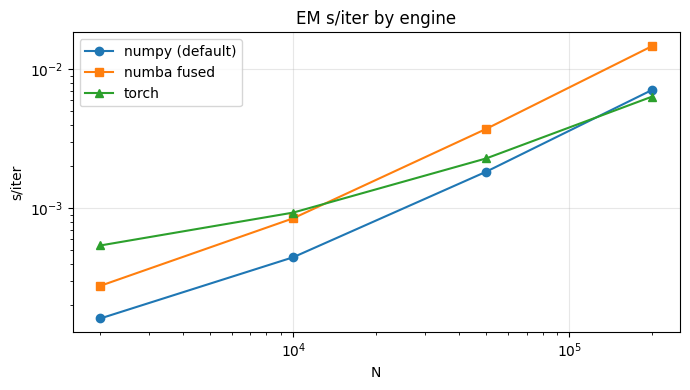

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(eng[:,0],eng[:,1],'o-',label='numpy (default)')
ax.plot(eng[:,0],eng[:,2],'s-',label='numba fused')
if torch_eng is not None: ax.plot(eng[:,0],eng[:,3],'^-',label='torch')
ax.set(title='EM s/iter by engine', xlabel='N', ylabel='s/iter'); ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## The score + estimate double pass
Each `optimize` iteration does an E/M step (`seq_estimate`, which scores the components to form posteriors) and a separate convergence-LL pass (`seq_log_density_sum`). Both score the emissions, so the LL pass is largely redundant work. Here is its share of per-iteration time, followed by the built-in fix: `optimize(reuse_estep_ll=True)` reuses the E-step's likelihood (posterior normalizer for mixtures, forward pass for HMMs, variational ELBO for topic models) as the convergence likelihood, skipping the second pass -- available for every latent family.

As of the current release this fused path is the default (`reuse_estep_ll=True`); the cell below contrasts it against `reuse_estep_ll=False`, the old per-iteration-scoring behavior.


In [4]:
data = truth().sampler(1).sample(100_000)
est = mk_est(); enc = seq_encode(data, model=truth()); m = seq_estimate(enc, est, prev_estimate=truth())
from mixle.stats.compute.sequence import seq_estimate as _se
t_step = bench(lambda: _se(enc, est, prev_estimate=m))
t_ll   = bench(lambda: seq_log_density_sum(enc, m))
print('E/M step (seq_estimate):           %.4f s' % t_step)
print('convergence LL (seq_log_density):  %.4f s' % t_ll)
print('LL pass is %.0f%% of the per-iteration work (delta-based convergence pays this every iter)'
      % (100*t_ll/(t_step+t_ll)))

E/M step (seq_estimate):           0.0036 s
convergence LL (seq_log_density):  0.0032 s
LL pass is 47% of the per-iteration work (delta-based convergence pays this every iter)


In [5]:
# optimize(reuse_estep_ll=True) reuses the E-step likelihood normalizer (top-level mixtures,
# default local engine). Fixed-iteration fits are identical; convergence reaches the same optimum.
big = truth().sampler(1).sample(200_000)
def fit(reuse):
    return optimize(big, mk_est(), max_its=40, delta=None, rng=np.random.RandomState(1),
                    out=io.StringIO(), reuse_estep_ll=reuse)
fit(False); fit(True)  # warm
import time
t0=time.perf_counter(); m_std=fit(False); t_std=time.perf_counter()-t0
t0=time.perf_counter(); m_fast=fit(True); t_fast=time.perf_counter()-t0
enc=seq_encode(big, model=m_std)
print('standard 40 its:        %.3f s' % t_std)
print('reuse_estep_ll 40 its:  %.3f s  (%.2fx faster)' % (t_fast, t_std/t_fast))
print('identical fit: weights match =', np.allclose(m_std.w, m_fast.w, atol=1e-10))

standard 40 its:        0.531 s
reuse_estep_ll 40 its:  0.306 s  (1.73x faster)
identical fit: weights match = True


### Takeaways
- numpy/numba dominate at small-to-medium N (no device-transfer overhead); torch overtakes only at large N (and shines on GPU / for autograd-based fitting). Pick the engine by data size.
- The convergence-LL pass is a real, recurring overhead (~half of per-iteration work). `optimize` removes it by default (`reuse_estep_ll=True`) for every latent family on the default engine (mixtures, HMMs and their variants, topic models -- LDA/LLDA/PLSI --, associations, and the Indian-buffet/Markov-transform models) by reusing the E-step's likelihood normalizer / forward pass / variational ELBO - measured ~1.7× faster per iteration here, with identical fixed-iteration fits and the same converged optimum (default off preserves exact historical behavior; other models fall back automatically).
